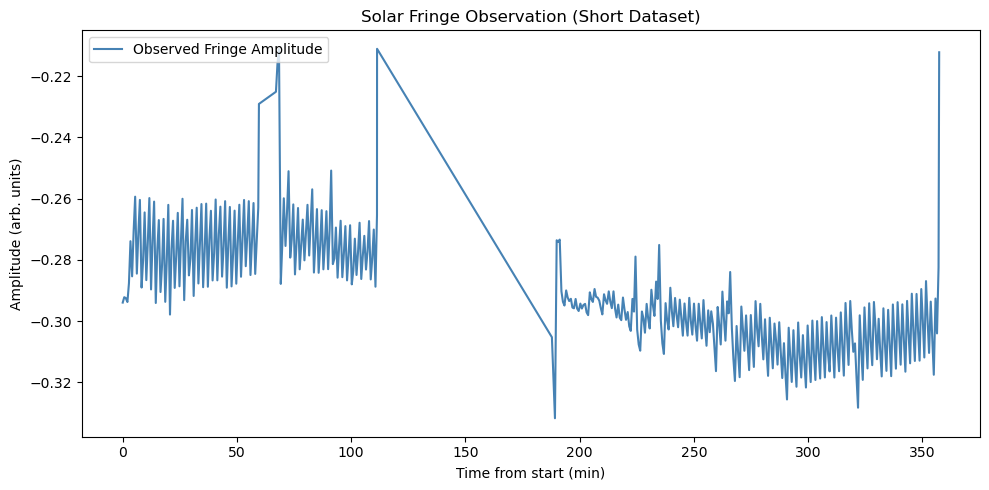

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
from astropy.coordinates import EarthLocation, get_sun
import astropy.units as u

# --- Load your .npz data ---
data = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB3/DATA/RTFM_4_3_spectra.npz")

# --- Helper: Julian Date → Unix time ---
def jd_to_unix(jd_array):
    t = Time(jd_array, format='jd')
    return t.unix

# --- Helper: Compute hour angles ---
def compute_hour_angles(jd_array, lat, lon):
    t = Time(jd_array, format='jd', scale='utc')
    location = EarthLocation(lat=lat*u.deg, lon=lon*u.deg)
    sun_coord = get_sun(t)
    lst = t.sidereal_time('mean', longitude=location.lon)
    ha = (lst - sun_coord.ra).to(u.rad).value
    ha = (ha + np.pi) % (2*np.pi) - np.pi  # wrap between -π and π
    return ha

# --- Observatory & Sun parameters ---
lat = 37.0             # degrees
lon = -122.0           # degrees
delta = np.radians(23.0)  # Sun declination
b_ew = 20.0            # m
b_ns = 0.0             # m
lam = 0.025            # m (X-band wavelength)

# --- Prepare data ---
times = jd_to_unix(data['jd'])
ha = compute_hour_angles(data['jd'], lat, lon)
band_amp = np.mean(data['spec_real'], axis=1)  # band-averaged amplitude
dt_min = (times - times[0]) / 60  # minutes from start

# --- Plot observed fringes ---
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(dt_min, band_amp, color='steelblue', label='Observed Fringe Amplitude')

ax.set_xlabel('Time from start (min)')
ax.set_ylabel('Amplitude (arb. units)')
ax.set_title('Solar Fringe Observation (Short Dataset)')
ax.legend(loc='upper left')
fig.tight_layout()
plt.show()

In [98]:
# --- Basic dataset metadata ---
num_observations = len(data['jd'])
num_channels = data['spec_real'].shape[1]  # number of frequency channels
time_start = Time(data['jd'][0], format='jd').iso
time_end   = Time(data['jd'][-1], format='jd').iso
total_duration_sec = (Time(data['jd'][-1], format='jd').unix -
                      Time(data['jd'][0], format='jd').unix)
integration_time_sec = total_duration_sec / num_observations
band_mean = np.mean(data['spec_real'])
band_std  = np.std(data['spec_real'])

# --- Print summary ---
print("=== Fringe Observation Summary ===")
print(f"Number of observations: {num_observations}")
print(f"Number of frequency channels: {num_channels}")
print(f"Observation start: {time_start} UTC")
print(f"Observation end:   {time_end} UTC")
print(f"Total duration:    {total_duration_sec:.1f} s ({total_duration_sec/60:.1f} min)")
print(f"Approx. integration time per sample: {integration_time_sec:.2f} s")
print(f"Band-averaged amplitude: mean = {band_mean:.3f}, std = {band_std:.3f}")

=== Fringe Observation Summary ===
Number of observations: 401
Number of frequency channels: 1024
Observation start: 2026-04-02 18:01:00.957 UTC
Observation end:   2026-04-02 23:58:23.314 UTC
Total duration:    21442.4 s (357.4 min)
Approx. integration time per sample: 53.47 s
Band-averaged amplitude: mean = -0.291, std = 0.450


In [99]:
# --- imports ---
import numpy as np
from astropy.time import Time
from datetime import timezone, timedelta

# ============================================================
# 🔍 Inspector Function (No plotting)
# ============================================================
def inspect_data_summary(data, name="Dataset"):
    print(f"\n=== Inspecting {name} ===")

    # --- NPZ file ---
    if isinstance(data, np.lib.npyio.NpzFile):
        print("Type: NPZ file")
        keys = list(data.keys())
        print(f"Keys: {keys}")

        for key in keys:
            val = data[key]
            shape = getattr(val, 'shape', None)
            dtype = getattr(val, 'dtype', type(val))
            print(f"  - {key}: shape={shape}, dtype={dtype}")

            # Compute stats for large numeric arrays (2D+)
            if isinstance(val, np.ndarray) and np.issubdtype(val.dtype, np.number):
                if val.ndim >= 2:
                    print(f"      Min: {np.min(val):.3g}, Max: {np.max(val):.3g}, Mean: {np.mean(val):.3g}")

    # --- NumPy array ---
    elif isinstance(data, np.ndarray):
        print(f"Type: NumPy array, shape={data.shape}, dtype={data.dtype}")
        if np.issubdtype(data.dtype, np.number) and data.ndim >= 2:
            print(f"Min: {np.min(data):.3g}, Max: {np.max(data):.3g}, Mean: {np.mean(data):.3g}")

    # --- Pandas DataFrame ---
    elif 'pandas' in str(type(data)):
        print("Type: Pandas DataFrame")
        print(data.info())
        numeric_cols = data.select_dtypes(include=np.number)
        for col in numeric_cols:
            print(f"\n--- {col} ---")
            print(f"Min: {numeric_cols[col].min():.3g}")
            print(f"Max: {numeric_cols[col].max():.3g}")
            print(f"Mean: {numeric_cols[col].mean():.3g}")

    # --- Dictionary ---
    elif isinstance(data, dict):
        print("Type: Dictionary")
        print(f"Keys: {list(data.keys())}")
        for key, val in data.items():
            shape = getattr(val, 'shape', None)
            dtype = getattr(val, 'dtype', type(val))
            print(f"  - {key}: shape={shape}, dtype={dtype}")
            if isinstance(val, np.ndarray) and np.issubdtype(val.dtype, np.number) and val.ndim >= 2:
                print(f"      Min: {np.min(val):.3g}, Max: {np.max(val):.3g}, Mean: {np.mean(val):.3g}")

    else:
        print(f"Type: {type(data)}")
        print(data)

# ============================================================
# ⏱️ Time + Metadata Summary Function
# ============================================================
import time

def summarize_observation(data, utc_offset_hours=None):
    """
    Print useful observation metadata with local time first and UTC in parentheses.
    If utc_offset_hours is None, detect system local timezone automatically.
    """
    print("\n=== Observation Summary ===")

    if 'jd' not in data:
        print("No 'jd' (time) field found in dataset.")
        return

    jd = data['jd']
    num_observations = len(jd)

    # Convert to UTC
    t_start_utc = Time(jd[0], format='jd').to_datetime(timezone.utc)
    t_end_utc   = Time(jd[-1], format='jd').to_datetime(timezone.utc)

    # Determine local timezone
    if utc_offset_hours is None:
        # Use system local timezone
        local_offset_sec = -time.timezone if (time.localtime().tm_isdst == 0) else -time.altzone
        utc_offset_hours = local_offset_sec / 3600
        tz_name = time.tzname[time.localtime().tm_isdst]
    else:
        tz_name = f"UTC{utc_offset_hours:+d}"

    offset = timedelta(hours=utc_offset_hours)
    t_start_local = t_start_utc + offset
    t_end_local   = t_end_utc + offset

    # Duration / integration time
    unix_times = Time(jd, format='jd').unix
    total_duration = unix_times[-1] - unix_times[0]
    integration_time = total_duration / num_observations

    # Frequency/amplitude stats if present
    if 'spec_real' in data:
        num_channels = data['spec_real'].shape[1]
        if 'spec_imag' in data:
            amp = np.sqrt(data['spec_real']**2 + data['spec_imag']**2)
        else:
            amp = np.abs(data['spec_real'])
        band_mean = np.mean(amp)
        band_std  = np.std(amp)
    else:
        num_channels = "Unknown"
        band_mean = None
        band_std  = None

    # Print summary
    print(f"Number of observations: {num_observations}")
    print(f"Number of frequency channels: {num_channels}")
    print(f"Observation window:")
    print(f"   Start ({tz_name}): {t_start_local.strftime('%I:%M:%S %p')} "
          f"(UTC: {t_start_utc.strftime('%I:%M:%S %p')})")
    print(f"   End   ({tz_name}): {t_end_local.strftime('%I:%M:%S %p')} "
          f"(UTC: {t_end_utc.strftime('%I:%M:%S %p')})")
    print(f"Total duration: {total_duration/60:.1f} minutes")
    print(f"Integration time per sample: {integration_time:.1f} seconds")

    if band_mean is not None:
        print(f"Mean signal amplitude: {band_mean:.3f}")
        print(f"Signal variability (std): {band_std:.3f}")
        
# ============================================================
# 🧪 Smoke Tests
# ============================================================
# 🧪 Smoke Tests
def run_smoke_tests():
    print("\n=== Running Smoke Tests ===")
    try:
        inspect_data_summary(np.arange(100), "1D Test")
        print("Test 1 PASS")
    except Exception as e:
        print("Test 1 FAIL:", e)

    try:
        inspect_data_summary(np.random.rand(50, 50), "2D Test")
        print("Test 2 PASS")
    except Exception as e:
        print("Test 2 FAIL:", e)

    try:
        fake_dict = {'a': np.random.rand(100), 'b': np.random.rand(20, 30)}
        inspect_data_summary(fake_dict, "Dict Test")
        print("Test 3 PASS")
    except Exception as e:
        print("Test 3 FAIL:", e)

    print("=== Smoke Tests Complete ===")

In [100]:
data = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB3/DATA/RTFM_4_3_14.npz", allow_pickle=True)
#run_smoke_tests()
#inspect_data_summary(data, name="Solar Data")
summarize_observation(data)


=== Observation Summary ===
Number of observations: 247
Number of frequency channels: 1024
Observation window:
   Start (Pacific Daylight Time): 02:08:52 PM (UTC: 09:08:52 PM)
   End   (Pacific Daylight Time): 04:58:23 PM (UTC: 11:58:23 PM)
Total duration: 169.5 minutes
Integration time per sample: 41.2 seconds
Mean signal amplitude: 0.315
Signal variability (std): 0.454


In [101]:
file = "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB3/DATA/RTFM_4_3_14.npz"
data = np.load(file, allow_pickle = True)

power_imag = data["spec_imag"]
power_real = data["spec_real"]
power_complex = power_real + 1j * power_imag

=== Raw Data Shapes ===
Visibility real: (247, 1024)
Visibility imag: (247, 1024)
Frequencies: (247, 1024)
Times: (247,)


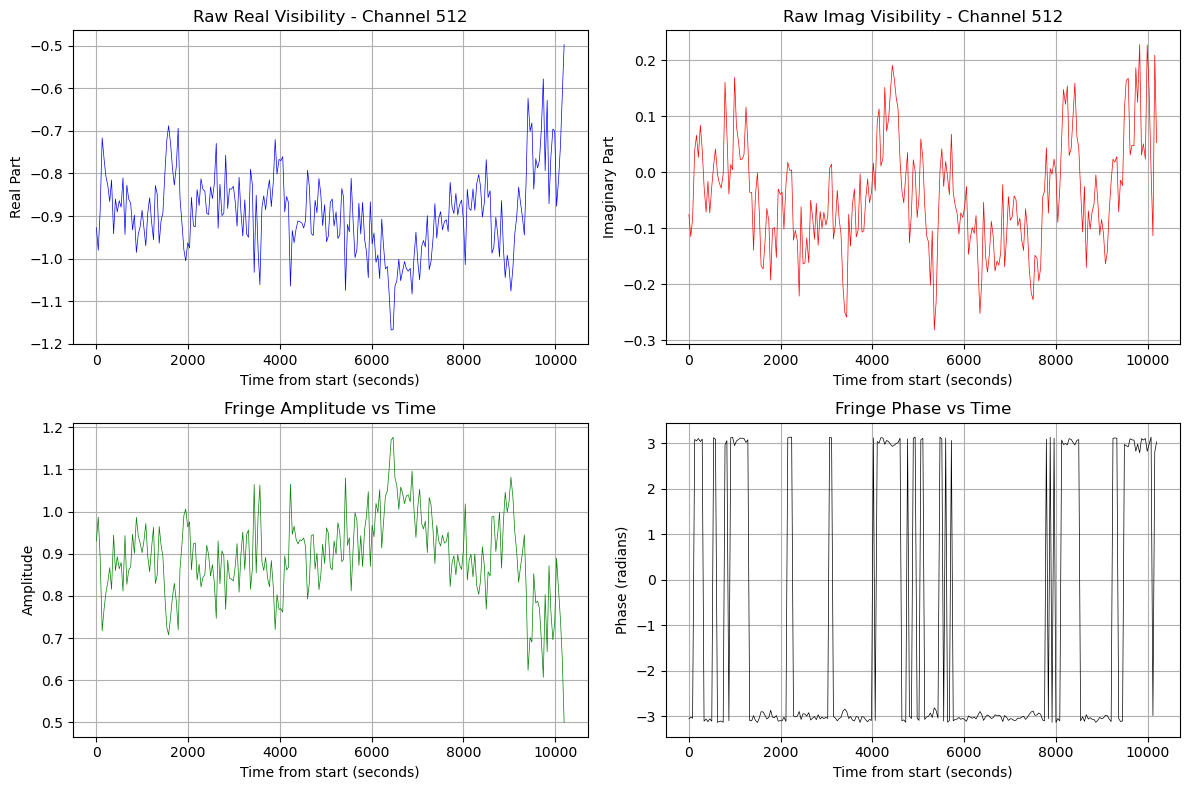

In [102]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
# Extract raw data
vis_real = data['spec_real']
vis_imag = data['spec_imag']
freqs = data['freq_axis']
times = (data['start_time'] + data['end_time']) / 2

print("=== Raw Data Shapes ===")
print(f"Visibility real: {vis_real.shape}")
print(f"Visibility imag: {vis_imag.shape}")
print(f"Frequencies: {freqs.shape}")
print(f"Times: {times.shape}")

# === PLOT 1: Single frequency channel vs time ===
chan = 512  # middle channel
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(times - times[0], vis_real[:, chan], 'b-', linewidth=0.5)
plt.xlabel('Time from start (seconds)')
plt.ylabel('Real Part')
plt.title(f'Raw Real Visibility - Channel {chan}')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(times - times[0], vis_imag[:, chan], 'r-', linewidth=0.5)
plt.xlabel('Time from start (seconds)')
plt.ylabel('Imaginary Part')
plt.title(f'Raw Imag Visibility - Channel {chan}')
plt.grid(True)

plt.subplot(2, 2, 3)
amp = np.sqrt(vis_real[:, chan]**2 + vis_imag[:, chan]**2)
plt.plot(times - times[0], amp, 'g-', linewidth=0.5)
plt.xlabel('Time from start (seconds)')
plt.ylabel('Amplitude')
plt.title('Fringe Amplitude vs Time')
plt.grid(True)

plt.subplot(2, 2, 4)
phase = np.arctan2(vis_imag[:, chan], vis_real[:, chan])
plt.plot(times - times[0], phase, 'k-', linewidth=0.5)
plt.xlabel('Time from start (seconds)')
plt.ylabel('Phase (radians)')
plt.title('Fringe Phase vs Time')
plt.grid(True)

plt.tight_layout()
plt.show()

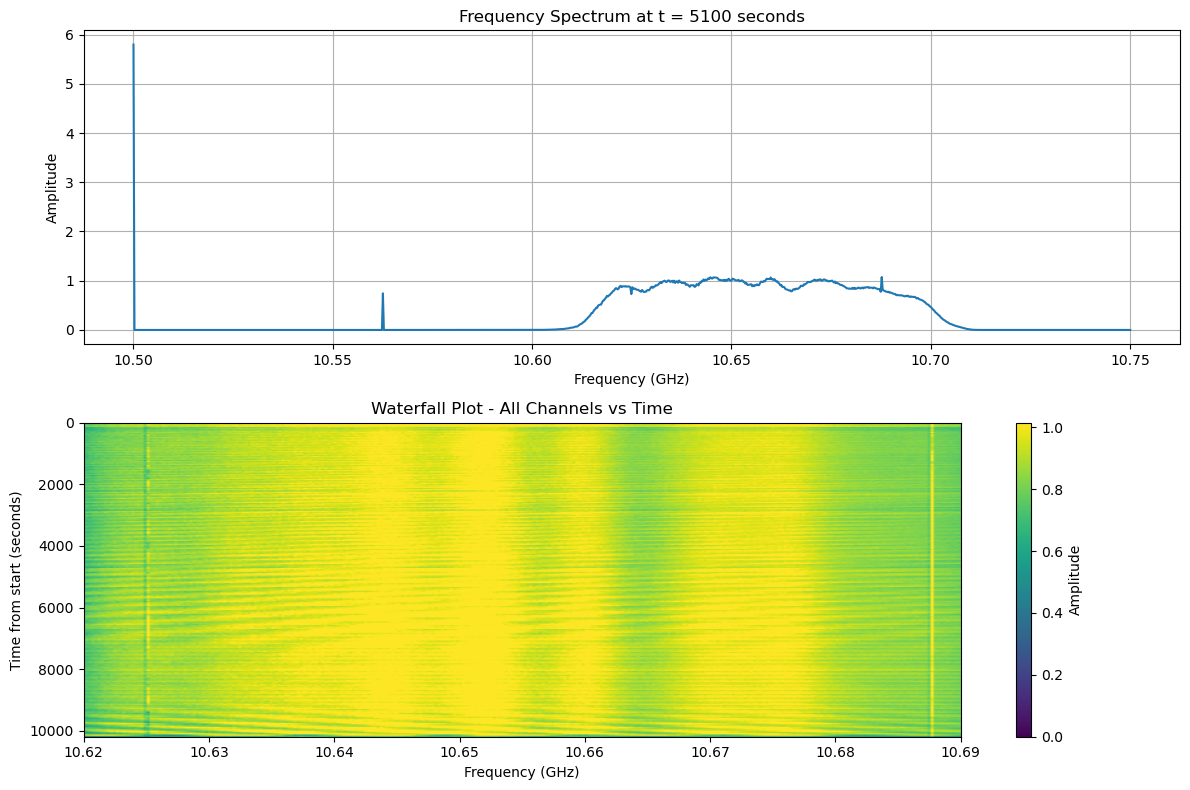

In [104]:
# === PLOT 2: Waterfall plot of all frequencies ===
plt.figure(figsize=(12, 8))

visibility = vis_real + 1j * vis_imag

# Take middle time sample
mid_time = vis_real.shape[0] // 2
amp_all = np.sqrt(vis_real[mid_time]**2 + vis_imag[mid_time]**2)

plt.subplot(2, 1, 1)
plt.plot(freqs[mid_time], amp_all)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Amplitude')
plt.title(f'Frequency Spectrum at t = {times[mid_time] - times[0]:.0f} seconds')
plt.grid(True)

# Waterfall plot
plt.subplot(2, 1, 2)
extent = [freqs[0,0], freqs[0,-1], times[-1]-times[0], 0]
plt.imshow(np.abs(visibility), aspect='auto', extent=extent, 
           cmap='viridis', vmin=0, vmax=np.percentile(np.abs(visibility), 95))
plt.colorbar(label='Amplitude')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Time from start (seconds)')
plt.title('Waterfall Plot - All Channels vs Time')
plt.xlim(10.62, 10.69)
plt.tight_layout()
plt.show()